In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [15]:
df = pd.read_csv('./data_thuydien/ThuyDien_hoa_binh_cleaned.csv')
df.head()

,ten_ho,thoi_diem,muc_nuoc_thuong_luu_m,muc_nuoc_dang_binh_thuong_m,muc_nuoc_chet_m,luu_luong_den_ho_m3_s,tong_luong_xa_m3_s,tong_luong_xa_qua_dap_tran_m3_s,tong_luong_xa_qua_nha_may_m3_s,so_cua_xa_sau,so_cua_xa_mat
0,Hòa Bình,2025-06-13 20:00:00,84.23,117,80,2091,2252,0,2252,0,0
1,Hòa Bình,2025-06-13 02:00:00,84.24,117,80,1764,2260,0,2260,0,0
2,Hòa Bình,2025-06-13 17:00:00,84.24,117,80,1923,2251,0,2251,0,0
3,Hòa Bình,2025-06-13 23:00:00,84.25,117,80,2884,2207,0,2207,0,0
4,Hòa Bình,2025-06-12 23:00:00,84.27,117,80,1430,2261,0,2261,0,0


# Step1: Loại bỏ một số cột không cần thiết

In [16]:
cols_to_drop = [
    "ten_ho",
    "muc_nuoc_dang_binh_thuong_m",
    "muc_nuoc_chet_m",
    "tong_luong_xa_qua_dap_tran_m3_s",
    "tong_luong_xa_qua_nha_may_m3_s",
    "so_cua_xa_sau",
    "so_cua_xa_mat",
]

missing = [c for c in cols_to_drop if c not in df.columns]
if missing:
    print("Cột không tìm thấy (bỏ qua khi xoá):", missing)


In [17]:
before_shape = df.shape
before_cols = set(df.columns)

df = df.drop(columns=cols_to_drop, errors="ignore")

after_shape = df.shape
dropped_effective = list(before_cols - set(df.columns))

print("ĐÃ XOÁ:", dropped_effective)
print("Shape trước -> sau:", before_shape, "->", after_shape)
print("Còn lại các cột:", list(df.columns))

df.to_csv("./data_thuydien/ThuyDien_hoa_binh_preprocessed_step1.csv", index=False, encoding="utf-8")


ĐÃ XOÁ: ['so_cua_xa_sau', 'tong_luong_xa_qua_nha_may_m3_s', 'muc_nuoc_chet_m', 'ten_ho', 'so_cua_xa_mat', 'tong_luong_xa_qua_dap_tran_m3_s', 'muc_nuoc_dang_binh_thuong_m']
Shape trước -> sau: (11088, 11) -> (11088, 4)
Còn lại các cột: ['thoi_diem', 'muc_nuoc_thuong_luu_m', 'luu_luong_den_ho_m3_s', 'tong_luong_xa_m3_s']


In [18]:
# chuẩn hoá tên cột (tránh lỗi do khoảng trắng)
df.columns = df.columns.str.strip()

# ép datetime (thử chuẩn ISO trước; nếu tỷ lệ NaT cao sẽ thử day-first)
s = pd.to_datetime(df["thoi_diem"], errors="coerce")
if s.notna().mean() < 0.95:  # nếu parse kém, thử day-first
    s = pd.to_datetime(df["thoi_diem"], errors="coerce", dayfirst=True)

# nếu có timezone, bỏ tz để so sánh/ngắt sort ổn định
try:
    s = s.dt.tz_localize(None)
except Exception:
    pass

df["thoi_diem"] = s

df = df.sort_values(
    by="thoi_diem",
    ascending=True,          # đổi thành False nếu cần giảm dần
    kind="mergesort",        # stable sort
    na_position="last"       # NaT (nếu còn) đẩy xuống cuối
).reset_index(drop=True)

In [19]:
print("Đã sort tăng dần theo thoi_diem?:", df["thoi_diem"].is_monotonic_increasing)
print(df[["thoi_diem"]].head(3))
print(df[["thoi_diem"]].tail(3))

df.to_csv("ThuyDien_hoa_binh_preprocessed_step1.csv", index=False, encoding="utf-8")

Đã sort tăng dần theo thoi_diem?: True
            thoi_diem
0 2022-01-01 02:00:00
1 2022-01-01 05:00:00
2 2022-01-01 08:00:00
                thoi_diem
11085 2025-10-17 17:00:00
11086 2025-10-17 20:00:00
11087 2025-10-17 23:00:00


# Xử lý trường thông tin `muc_nuoc_thuong_luu_m`

## Xử lý outlier, chú trọng việc xử lý theo từng tháng

Xử lý outlier các tháng không phải là tháng 6

In [20]:
import numpy as np
import pandas as pd

time_col   = "thoi_diem"
target_col = "muc_nuoc_thuong_luu_m"

df.columns = df.columns.str.strip()
assert pd.api.types.is_datetime64_any_dtype(df[time_col]), "thoi_diem chưa là datetime"
assert df[target_col].isna().sum() == 0, f"{target_col} còn NaN — cần làm sạch trước."

# Tháng phục vụ nhóm
m = df[time_col].dt.month


In [21]:
# Thống kê theo tháng
grp = df.groupby(m)[target_col]
q1  = grp.quantile(0.25)
q3  = grp.quantile(0.75)
iqr = q3 - q1
lb  = q1 - 1.5 * iqr
ub  = q3 + 1.5 * iqr

# Đếm outlier theo tháng
tmp = (
    df.assign(month=m)
      .merge(lb.rename("LB"), left_on="month", right_index=True)
      .merge(ub.rename("UB"), left_on="month", right_index=True)
)
tmp["is_out"] = (tmp[target_col] < tmp["LB"]) | (tmp[target_col] > tmp["UB"])

summary = (tmp.groupby("month")
              .agg(n=("is_out","size"),
                   n_out=("is_out","sum"),
                   LB=("LB","first"),
                   UB=("UB","first"))
              .reset_index()
              .sort_values("month"))
summary


,month,n,n_out,LB,UB
0,1,992,108,107.66000,121.50000
1,2,904,0,102.87000,119.77000
2,3,992,47,101.66500,116.74500
3,4,960,0,90.62625,127.27625
4,5,992,9,86.81125,123.66125
5,6,960,153,90.50000,118.18000
6,7,992,0,91.80000,114.36000
7,8,992,0,91.37625,115.06625
8,9,960,0,101.80125,120.33125
9,10,880,20,113.14875,118.79875


In [22]:
# Tháng cần xử lý (có ít nhất 1 outlier)
months_to_fix = set(summary.loc[summary["n_out"] > 0, "month"].astype(int).tolist())

# BỎ QUA THÁNG 6
months_to_fix -= {6}
print("Tháng sẽ được xử lý (đã loại bỏ 6):", sorted(months_to_fix))

# Map LB/UB chỉ cho các tháng cần xử lý
lb_map = {mon: lb.loc[mon] for mon in months_to_fix if mon in lb.index}
ub_map = {mon: ub.loc[mon] for mon in months_to_fix if mon in ub.index}

lb_vals = m.map(lb_map)   # tháng không xử lý -> NaN
ub_vals = m.map(ub_map)

# Outlier cần kẹp: thuộc months_to_fix và nằm ngoài [LB,UB]
mask_outlier = (
    lb_vals.notna() & ub_vals.notna() &
    ((df[target_col] < lb_vals) | (df[target_col] > ub_vals))
)

print("Số điểm outlier sẽ kẹp:", int(mask_outlier.sum()))

# Kẹp in-place về LB/UB của chính tháng đó
x   = df.loc[mask_outlier, target_col].values
lbs = lb_vals.loc[mask_outlier].values
ubs = ub_vals.loc[mask_outlier].values

df.loc[mask_outlier, target_col] = np.minimum(np.maximum(x, lbs), ubs)

print("ĐÃ winsor in-place cho các tháng có outlier (ngoại trừ tháng 6).")


Tháng sẽ được xử lý (đã loại bỏ 6): [1, 3, 5, 10, 11]
Số điểm outlier sẽ kẹp: 196
ĐÃ winsor in-place cho các tháng có outlier (ngoại trừ tháng 6).


In [23]:
# Rà soát còn outlier không (trên các tháng đã xử lý)
recheck = (
    df.assign(month=m)
      .merge(pd.Series(lb_map, name="LB"), left_on="month", right_index=True, how="left")
      .merge(pd.Series(ub_map, name="UB"), left_on="month", right_index=True, how="left")
)
recheck["is_out_after"] = (
    recheck["LB"].notna() & recheck["UB"].notna() &
    ((recheck[target_col] < recheck["LB"]) | (recheck[target_col] > recheck["UB"]))
)

report = (recheck[recheck["LB"].notna()]
          .groupby("month")["is_out_after"].sum()
          .reset_index()
          .rename(columns={"is_out_after":"n_out_after"})
          .sort_values("month"))
report

,month,n_out_after
0,1,0
1,3,0
2,5,0
3,10,0
4,11,0


Kiểm tra sau khi xử lý

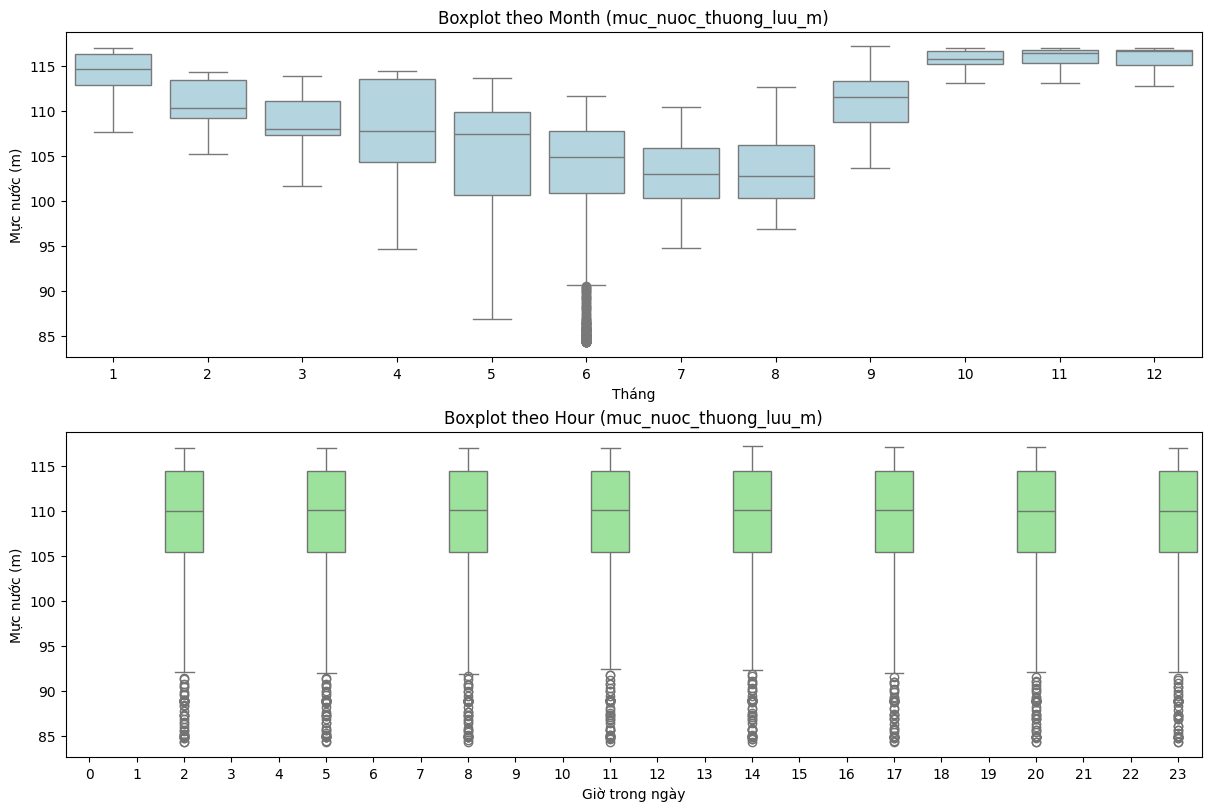

Đã lưu hình: ./data_thuydien/plots_preprocessed/muc_nuoc_thuong_luu_m_box_month_hour.png


In [24]:
import os
import seaborn as sns
import matplotlib.pyplot as plt

# Thư mục lưu ảnh
out_dir = "./data_thuydien/plots_preprocessed/"
os.makedirs(out_dir, exist_ok=True)

target = "muc_nuoc_thuong_luu_m"

# Tạo bản sao an toàn để vẽ
df_b = df.copy()

# Đảm bảo cột thời gian hợp lệ
assert pd.api.types.is_datetime64_any_dtype(df_b["thoi_diem"]), "Cột thoi_diem chưa phải datetime"

# Tạo cột month, hour phục vụ vẽ
df_b["month"] = df_b["thoi_diem"].dt.month
df_b["hour"]  = df_b["thoi_diem"].dt.hour

# Chuyển target sang numeric an toàn
df_b[target] = pd.to_numeric(df_b[target], errors="coerce")

# Thiết lập thứ tự trục
order_month = list(range(1, 13))
order_hour = list(range(0, 24))

# Vẽ 2 boxplot (2 hàng 1 cột)
fig, axes = plt.subplots(2, 1, figsize=(12, 8), constrained_layout=True)

sns.boxplot(x="month", y=target, data=df_b, order=order_month, ax=axes[0], color="lightblue")
axes[0].set_title(f"Boxplot theo Month ({target})")
axes[0].set_xlabel("Tháng")
axes[0].set_ylabel("Mực nước (m)")

sns.boxplot(x="hour", y=target, data=df_b, order=order_hour, ax=axes[1], color="lightgreen")
axes[1].set_title(f"Boxplot theo Hour ({target})")
axes[1].set_xlabel("Giờ trong ngày")
axes[1].set_ylabel("Mực nước (m)")

# Lưu và hiển thị
fn = os.path.join(out_dir, f"{target}_box_month_hour.png")
fig.savefig(fn, dpi=150, bbox_inches="tight")
plt.show()
plt.close()

print("Đã lưu hình:", fn)


Xử lý tháng 6